# 💰 Module 3: Portfolio Performance Tracking

## 🎯 Objective

In this module, you will combine the cleaned trading data with historical market prices to calculate **the daily value of your portfolio over time**.

This is a crucial step in financial analysis — transforming trade logs into time series you can analyze, backtest, and report on.

By the end of this module, you'll be able to:
✅ Retrieve historical price data,  
✅ Reconstruct portfolio positions over time,  
✅ Calculate the total portfolio value per day.

---

## Step 3.0 – Import necessary libraries

💡 Tip: We will use `pandas` for data handling and `yfinance` to get price data.


In [12]:
# 💡 Tip: Import pandas and yfinance
# YOUR CODE HERE
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

## Step 3.1 – Load the cleaned dataset

💡 Tip: Load the `Clean_Data` CSV file saved in Module 2.


In [4]:
# 💡 Tip: Use pd.read_csv()
df = pd.read_csv("Clean_Data")
# YOUR CODE HERE
df = df.sort_values(by="Date")
df = df.reset_index(drop=True)
df

,Asset,Quantity,Price,Date,Type
0,AAPL,96.0,720.35,2024-05-26,BUY
1,TSLA,9.0,916.00,2024-07-14,SELL
2,AAPL,95.0,265.12,2024-09-01,SELL
3,TSLA,59.0,667.38,2024-09-06,SELL
4,AMZN,15.0,1455.88,2024-10-28,SELL
5,AMZN,51.0,591.58,2024-12-07,SELL
6,TSLA,2.0,599.67,2025-02-04,SELL
7,AMZN,58.0,1182.83,2025-02-04,SELL
8,TSLA,46.0,1145.42,2025-03-23,SELL
9,AAPL,96.0,1303.32,2025-04-06,BUY


## Step 3.2 – Get the list of unique assets

💡 Tip: Extract unique tickers from the 'Asset' column.


In [5]:
# 💡 Tip: Use .unique() on the 'Asset' column
df["Asset"].unique()
# YOUR CODE HERE

array(['AAPL', 'TSLA', 'AMZN'], dtype=object)

## Step 3.3 – Download historical prices

💡 Tip: Use yfinance.download() to get adjusted close prices for all assets.

Make sure you define the start and end dates!


In [6]:
# 💡 Tip: Define start_date and end_date, then call yf.download()
start_date = "2024-5-26"
end_date = "2025-4-6"
data = yf.download(df["Asset"].unique().tolist(), start=start_date,end=end_date)
# YOUR CODE HERE


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  3 of 3 completed


## Step 3.4 – Build the position matrix

💡 Tip: For each date, calculate how many units you hold per asset.

This requires looping through the trades and updating the positions over time.


In [7]:
# 💡 Tip: Create a DataFrame with zeros, loop over trades, adjust quantities
price_data = df[["Date", "Asset", "Price"]]

daily_prices = price_data.groupby(["Date", "Asset"]).last().reset_index()

price_matrix = daily_prices.pivot(index="Date", columns="Asset", values="Price")

position_matrix = pd.DataFrame(0, index=price_matrix.index, columns=df["Asset"].unique())

for _, trade in df.iterrows():
    date = trade["Date"]
    asset = trade["Asset"]
    qty = trade["Quantity"]
    position_matrix.loc[date:, asset] += qty
# YOUR CODE HERE
position_matrix

,AAPL,TSLA,AMZN
Date,,,
2024-05-26,96,0,0
2024-07-14,96,9,0
2024-09-01,191,9,0
2024-09-06,191,68,0
2024-10-28,191,68,15
2024-12-07,191,68,66
2025-02-04,191,70,124
2025-03-23,191,116,124
2025-04-06,287,116,124


## Step 3.5 – Calculate daily portfolio value

💡 Tip: Multiply the position matrix by daily prices, then sum across all assets.


In [16]:
# 💡 Tip: Element-wise multiply, then sum along columns
portfolio_value = (position_matrix * price_matrix).sum(axis=1)
portfolio_value
# YOUR CODE HERE


Date
2024-05-26     69153.60
2024-07-14      8244.00
2024-09-01     50637.92
2024-09-06     45381.84
2024-10-28     21838.20
2024-12-07     39044.28
2025-02-04    188647.82
2025-03-23    132868.72
2025-04-06    374052.84
dtype: float64

## Step 3.6 – Plot the portfolio value

💡 Tip: Use .plot() from matplotlib or pandas to visualize the time series.


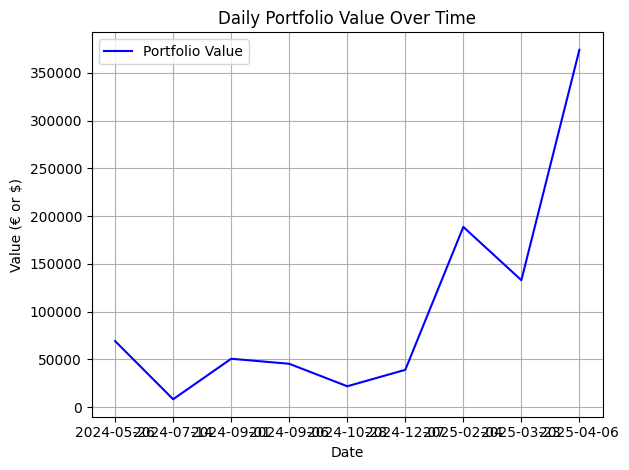

In [17]:
# 💡 Tip: Use matplotlib.pyplot and plot the series
plt.plot(portfolio_value, label='Portfolio Value', color='blue')
plt.title('Daily Portfolio Value Over Time')
plt.xlabel('Date')
plt.ylabel('Value (€ or $)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
# YOUR CODE HERE


## 📦 Save the portfolio value series

💡 Tip: Save the portfolio value series as a CSV file for future analysis.


In [18]:
# 💡 Tip: Use .to_csv()
portfolio_value.to_csv("Portfolio_Value", index=False)
# YOUR CODE HERE


## 📘 Report

Write a short report (in markdown or as comments):
- What was the starting value?
- What is the current value?
- Did you notice periods of strong growth or big drawdowns?

Reflect on how trade data transforms into performance insights.

---

You're now ready to calculate returns, volatility, and risk-adjusted performance metrics!
